**Purpose:** To explore the basics of pytorch\
**Date:** March 1, 2026

# 1. Quick start

In [60]:
# Import packages
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [61]:
# Loading the data
## Download training data
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

## Download test data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [62]:
# Batch size and data loader
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
  print(f"Shape of X [N, C, H, W]: {X.shape}")
  print(f"Shape of y: {y.shape} {y.dtype}")
  break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [63]:
# Create the model
## Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"
## Define model
class NeuralNetwork(nn.Module):
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [64]:
# Optimizing the model parameters
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [65]:
# Function for training the model
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    # prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), (batch + 1)* len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [66]:
# Evaluating the model's performance
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct): > 0.1f}%, Avg loss: {test_loss: > 8f} \n")

In [67]:
# Training
epochs = 5
for t in range(epochs):
  print(f"Epoch {t+1}\n--------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
--------------
loss: 2.301847 [   64/60000]
loss: 0.549918 [ 6464/60000]
loss: 0.385094 [12864/60000]
loss: 0.494097 [19264/60000]
loss: 0.445541 [25664/60000]
loss: 0.420083 [32064/60000]
loss: 0.376094 [38464/60000]
loss: 0.529728 [44864/60000]
loss: 0.462701 [51264/60000]
loss: 0.483512 [57664/60000]
Test Error: 
 Accuracy:  84.5%, Avg loss:  0.426199 

Epoch 2
--------------
loss: 0.281756 [   64/60000]
loss: 0.356506 [ 6464/60000]
loss: 0.268610 [12864/60000]
loss: 0.414630 [19264/60000]
loss: 0.377522 [25664/60000]
loss: 0.387726 [32064/60000]
loss: 0.324118 [38464/60000]
loss: 0.468733 [44864/60000]
loss: 0.370529 [51264/60000]
loss: 0.439775 [57664/60000]
Test Error: 
 Accuracy:  85.2%, Avg loss:  0.392700 

Epoch 3
--------------
loss: 0.210058 [   64/60000]
loss: 0.335233 [ 6464/60000]
loss: 0.223578 [12864/60000]
loss: 0.309333 [19264/60000]
loss: 0.367149 [25664/60000]
loss: 0.342123 [32064/60000]
loss: 0.288831 [38464/60000]
loss: 0.402544 [44864/60000]
loss: 0.300

In [68]:
# Use the model for prediction
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
model.eval()
x, y = test_data[4][0], test_data[4][1]
with torch.no_grad():
  x = x.to(device)
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]
  print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Shirt", Actual: "Shirt"


# 2. Tensors

In [69]:
# Initializing a tensor directly from data
data = [[1,2], [3,4]]
x_data = torch.tensor(data)
x_data

tensor([[1, 2],
        [3, 4]])

In [70]:
# Initialize tensor from numpy array
import numpy as np
np_array = np.array(data)
x_np = torch.tensor(np_array)

In [71]:
# From another tensor
x_ones = torch.ones_like(x_data)
print(f"Ones tensor \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float)
print(f"Random tensor \n {x_rand} \n")

Ones tensor 
 tensor([[1, 1],
        [1, 1]]) 

Random tensor 
 tensor([[0.3584, 0.6206],
        [0.4998, 0.1686]]) 



In [72]:
# From a shape
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random tensor \n {rand_tensor} \n")
print(f"Ones tensor \n {ones_tensor} \n")
print(f"Zeros tensor: \n {zeros_tensor} \n")

Random tensor 
 tensor([[0.5485, 0.1397, 0.7046],
        [0.2991, 0.1123, 0.9685]]) 

Ones tensor 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



In [73]:
# Check accelerator
torch.accelerator.is_available()

True

In [74]:
# Transfer to gpu
tensor = torch.rand(3,4)
tensor = tensor.to(device)

In [75]:
# Slicing and indexing
tensor = torch.ones(6, 6)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")

First row: tensor([1., 1., 1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1., 1., 1.])


In [76]:
# Set the values in the second column to 0
tensor[:, 1] = 0
tensor

tensor([[1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1.]])

In [77]:
# Concatenation
t1 = torch.cat([tensor, tensor], dim = 1)
t1

tensor([[1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.]])

In [78]:
# Multiplication
torch.matmul(tensor, tensor.T)

tensor([[5., 5., 5., 5., 5., 5.],
        [5., 5., 5., 5., 5., 5.],
        [5., 5., 5., 5., 5., 5.],
        [5., 5., 5., 5., 5., 5.],
        [5., 5., 5., 5., 5., 5.],
        [5., 5., 5., 5., 5., 5.]])

In [79]:
# Single-element tensors
agg = tensor.sum()
agg_item = agg.item() # numerical value
agg_item

30.0

In [80]:
# inplace operations
tensor.add_(5)
tensor

tensor([[6., 5., 6., 6., 6., 6.],
        [6., 5., 6., 6., 6., 6.],
        [6., 5., 6., 6., 6., 6.],
        [6., 5., 6., 6., 6., 6.],
        [6., 5., 6., 6., 6., 6.],
        [6., 5., 6., 6., 6., 6.]])

In [81]:
# tensor to numpy array
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [82]:
# From numpy to tensor
np_array = np.random.rand(5)
t = torch.from_numpy(np_array)
t

tensor([0.7300, 0.7227, 0.3293, 0.6268, 0.6681], dtype=torch.float64)

# Datasets and DataLoaders

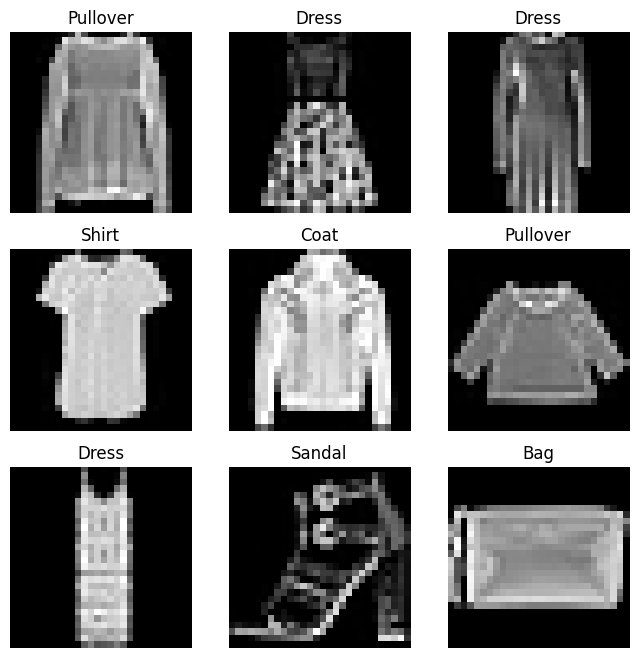

In [83]:
# Iterate of the loaded data
import matplotlib.pyplot as plt
labels_map = dict(zip(range(10), classes))
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  img, label = training_data[sample_idx]
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [84]:
# Creating a custom dataset
import pandas as pd
from torchvision.io import decode_image
import os
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_dir)

  def __getitem_(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels[idx, 0])
    image = decode.image(img_path)
    label = self.img_labels[idx, 1]
    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      image = self.target_transform(label)
    return image, label

In [85]:
# DataLoader
train_dataloader = DataLoader(training_data, batch_size = 64, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = 64, shuffle = True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


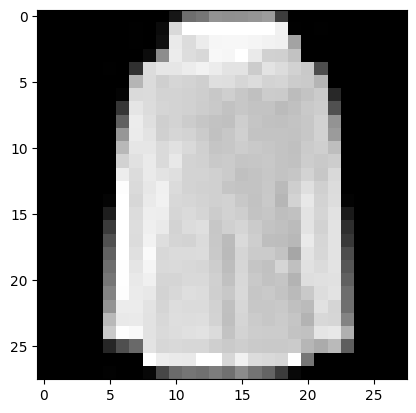

Label: 4


In [86]:
# Display image and label
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# 4. Transforms

In [87]:
from torchvision.transforms import ToTensor, Lambda

In [88]:
# Dataset
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

# 5. Build the neural network

## Model layers

In [89]:
imput_image = torch.rand(3, 28, 28)
print(imput_image.size())

torch.Size([3, 28, 28])


In [90]:
# nn.Flatten
flatten = nn.Flatten()
flat_image = flatten(imput_image)
print(flat_image.size())

torch.Size([3, 784])


In [91]:
# nn.Linear
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [92]:
# Activation function
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-1.5048e-02,  8.1379e-02,  4.4172e-01,  2.5323e-01, -1.7131e-01,
         -3.6275e-04, -8.2645e-01, -2.1316e-01,  8.5457e-02,  1.9135e-01,
         -1.6785e-01,  3.9633e-01,  3.7167e-01, -4.5747e-01, -1.0500e-01,
         -4.7026e-02,  3.7474e-01, -7.7246e-01,  9.1644e-02,  2.4505e-01],
        [-2.3877e-01,  2.9330e-02,  4.1018e-01,  4.9316e-02, -5.2277e-01,
         -1.1963e-01, -1.2082e+00, -4.2666e-01,  2.9040e-01,  8.4399e-02,
         -3.7402e-02,  5.9040e-01,  1.3518e-01, -6.8717e-02, -6.7946e-02,
         -7.7042e-02,  2.8030e-01, -6.9478e-01,  1.5048e-01,  4.6401e-02],
        [-2.7241e-01, -7.4113e-02,  4.9532e-01,  2.1107e-01, -5.6486e-01,
         -5.7247e-02, -4.8140e-01, -3.9884e-01,  3.8372e-02,  9.3365e-02,
         -9.1134e-02,  4.3203e-01,  3.8619e-01, -3.3797e-01, -2.6117e-01,
          6.1697e-02,  5.1190e-01, -5.0791e-01,  2.4009e-01,  4.4170e-02]],
       grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0814, 0.4417, 0.2532, 0.0000,

In [93]:
# nn.Sequential
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10))
input_image = torch.rand(3, 28, 28)
logits = seq_modules(input_image)

In [94]:
# nn.Softmax
softmax = nn.Softmax(dim = 1)
pred_prob = softmax(logits)
pred_prob

tensor([[0.0868, 0.0848, 0.0906, 0.0874, 0.1526, 0.1188, 0.1134, 0.0812, 0.0849,
         0.0995],
        [0.0993, 0.1003, 0.0848, 0.0870, 0.1326, 0.1078, 0.1094, 0.0836, 0.0899,
         0.1053],
        [0.0994, 0.1052, 0.0843, 0.0834, 0.1378, 0.1044, 0.1025, 0.0836, 0.0944,
         0.1050]], grad_fn=<SoftmaxBackward0>)

In [95]:
# model parameters
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
  print(f"Layer: {name} | Size: {param.size()} | Values: {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values: tensor([[ 0.0130,  0.0271, -0.0284,  ...,  0.0161,  0.0310,  0.0220],
        [-0.0370, -0.0884, -0.1033,  ..., -0.0463, -0.0344, -0.0783]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values: tensor([-0.0297, -0.0454], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values: tensor([[ 0.0220,  0.0307, -0.0098,  ...,  0.0374, -0.0330,  0.0959],
        [-0.0003,  0.0321,  0.0422,  ..., -0.0228,  0.0313, -0.1252]],
       device='cuda:0', grad_fn=<Slice

# 6. Automatic differentiation

In [97]:
x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [98]:
# Computing gradients
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.2103, 0.3242, 0.0900],
        [0.2103, 0.3242, 0.0900],
        [0.2103, 0.3242, 0.0900],
        [0.2103, 0.3242, 0.0900],
        [0.2103, 0.3242, 0.0900]])
tensor([0.2103, 0.3242, 0.0900])


In [99]:
z = torch.matmul(x, w) + b
print(z.requires_grad)

with torch.no_grad():
  z = torch.matmul(x, w) + b
print(z.requires_grad)

True
False


In [100]:
z = torch.matmul(x, w) + b
z_det = z.detach()
print(z_det.requires_grad)

False


In [101]:
# Jacobian product
inp = torch.eye(4, 5, requires_grad=True)
out = (inp+1).pow(2).t()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"First call\n{inp.grad}")
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nSecond call\n{inp.grad}")
inp.grad.zero_()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nCall after zeroing gradients\n{inp.grad}")

First call
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])

Second call
tensor([[8., 4., 4., 4., 4.],
        [4., 8., 4., 4., 4.],
        [4., 4., 8., 4., 4.],
        [4., 4., 4., 8., 4.]])

Call after zeroing gradients
tensor([[4., 2., 2., 2., 2.],
        [2., 4., 2., 2., 2.],
        [2., 2., 4., 2., 2.],
        [2., 2., 2., 4., 2.]])
